# Lab Assignment–2

## 1. Implement a Feedforward Neural Network (FNN) for a regression problem using the Graduate Admission Dataset.
    a) Build the FNN with two hidden layers, each having 7 neurons and ReLU activation function
    b) Train the model
    c) Visualise and compare the training and validation loss across epochs
    d) Evaluate the model on the test set and report test loss along with relevant regression metrics such as R-squared

In [165]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, TensorDataset

In [182]:
def train_model(model, train_loader, val_loader, criterion, optimizer, epochs):
    train_losses,val_losses =[], []

    for _ in range(epochs):
        model.train()
        total_loss,correct,total = 0, 0, 0
        for X, y in train_loader:
            optimizer.zero_grad()
            out = model(X)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            if y.ndim == 2:
                preds=(out>0.5).float()
        train_losses.append(total_loss/len(train_loader))
        model.eval()
        total_loss, correct, total = 0, 0, 0
        with torch.no_grad():
            for X, y in val_loader:
                out = model(X)
                loss = criterion(out, y)
                total_loss+= loss.item()
                if y.ndim ==2:
                    preds= (out > 0.5).float()
        val_losses.append(total_loss / len(val_loader))
    return train_losses,val_losses

In [183]:
def plot_curve(train, val, ylabel, title):
    plt.figure()
    plt.plot(train, label="Train")
    plt.plot(val, label="Validation")
    plt.xlabel("Epochs")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.show()

In [184]:
def loader(X, y):
    return DataLoader(TensorDataset(torch.tensor(X, dtype=torch.float32), torch.tensor(y, dtype=torch.float32)),
    batch_size=32, shuffle=True)

In [185]:
df = pd.read_csv("Graduate Admission Dataset.csv")
X = df.drop(columns=["Chance of Admit "]).values
y = df["Chance of Admit "].values.reshape(-1, 1)

In [186]:
scaler = StandardScaler()
X = scaler.fit_transform(X)

X_train,X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3)
X_val,X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5)

In [187]:
train_ds = TensorDataset(torch.tensor(X_train, dtype=torch.float32), torch.tensor(y_train, dtype=torch.float32))
val_ds = TensorDataset(torch.tensor(X_val, dtype=torch.float32),torch.tensor(y_val, dtype=torch.float32))
test_ds = TensorDataset(torch.tensor(X_test, dtype=torch.float32),torch.tensor(y_test, dtype=torch.float32))

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=32)
test_loader = DataLoader(test_ds, batch_size=32)

In [188]:
class FNNReg(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 7),
            nn.ReLU(),
            nn.Linear(7, 7),
            nn.ReLU(),
            nn.Linear(7, 1)
        )

    def forward(self, x):
        return self.net(x)

In [190]:
model = FNNRegression(X.shape[1])
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(),lr=0.001)
train_losses,val_losses = train_model(model,train_loader,val_loader,criterion,optimizer,epochs=100)

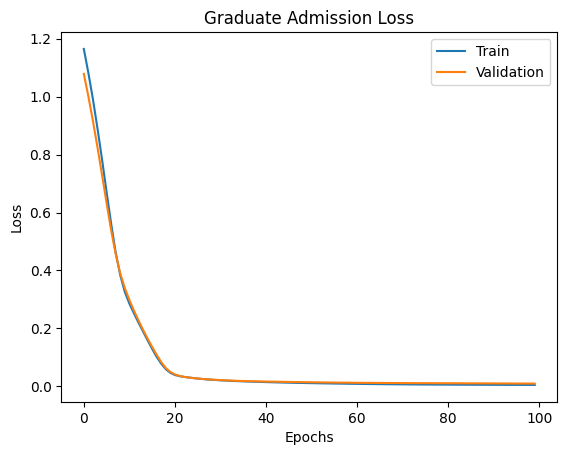

In [191]:
plot_curves(train_losses,val_losses,"Loss","Graduate Admission Loss")

In [192]:
model.eval()
y_true, y_pred = [],[]
with torch.no_grad():
    for Xb, yb in test_loader:
        out = model(Xb)
        y_true.extend(yb.numpy())
        y_pred.extend(out.cpu().numpy())

print("Test MSE:", np.mean((np.array(y_true)-np.array(y_pred))**2))
print("R2 Score:", r2_score(y_true,y_pred))

Test MSE: 0.0065368204
R2 Score: 0.7005975525562953


## 2. Implement a Feedforward Neural Network (FNN) using the Heart Disease Dataset. 

### a) Build the FNN using the following architecture:
    • ReLU-activated dense layer with 8 neurons
    • ReLU-activated dense layer with 4 neurons
    • Sigmoid-activated output layer with 1 neuron
### b) Train the model without dropout and evaluate its performance
### c) Modify the network architecture by introducing dropout layers:
    • 50% dropout in the first hidden layer
    • 30% dropout in the second hidden layer
### d) Visualize and compare the training and validation performance for both models (with and without dropout):
    • Training and validation loss
    • Training and validation accuracy
### e) Analyze how dropout affects model generalization and overfitting behavior

In [193]:
df1 = pd.read_csv("heart disease.csv")
X1 = StandardScaler().fit_transform(df1.drop(columns=["target"]).values)
y1 = df1["target"].values.reshape(-1, 1)

In [194]:
X1_train, X1_temp, y1_train, y1_temp = train_test_split(X1, y1, test_size=0.3)
X1_val, X1_test, y1_val, y1_test = train_test_split(X1_temp, y1_temp, test_size=0.5)

In [195]:
train1_loader = loader(X1_train, y1_train)
val1_loader = loader(X1_val, y1_val)
test1_loader = loader(X1_test, y1_test)

In [196]:
class HeartNet(nn.Module):
    def __init__(self, drop=False):
        super().__init__()
        layers = [nn.Linear(X.shape[1], 8), nn.ReLU()]
        if drop:
            layers.append(nn.Dropout(0.5))
        layers += [nn.Linear(8, 4), nn.ReLU()]
        if drop:
            layers.append(nn.Dropout(0.3))
        layers += [nn.Linear(4, 1), nn.Sigmoid()]
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

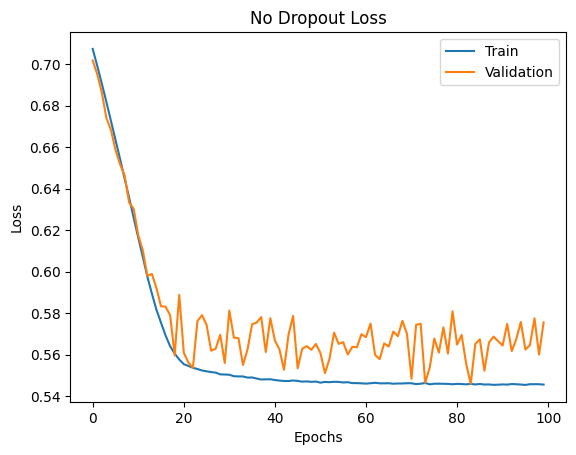

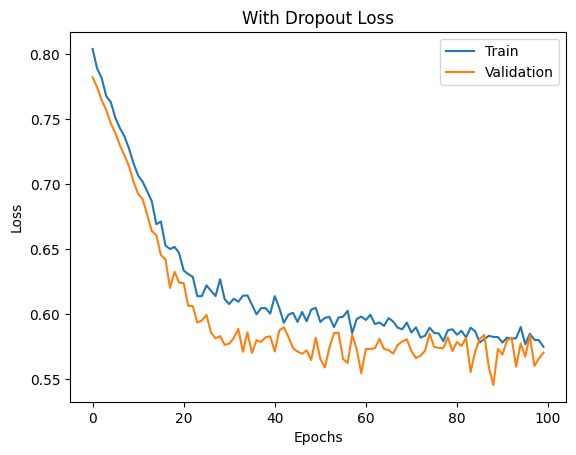

In [197]:
for name, drop in [("No Dropout", False), ("With Dropout", True)]:
    model = HeartNet(drop)
    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    tl, vl= train_model(model,loader(X_train, y_train), loader(X_val, y_val),criterion, optimizer, epochs=100)

    plot_curve(tl, vl, "Loss", f"{name} Loss")

## 3. Implement a Feedforward Neural Network (FNN) using the Modified Fashion MNIST Dataset.

### a) Experiment with the following hyperparameters to optimize the FNN:
    • Number of hidden layers (eg: 1,2)
    • Number of neurons per layer(eg : [128], [128,64])
    • Number of epochs (eg: 10, 20)
    • Learning rate (eg : 0.001, 0.0005)
    • Dropout rate (eg : 0.1, 0.2)
    • Batch size (eg: 16, 32)
    • Optimizer (eg : Adam, RMSprop)
### b) Train the model and identify the best configuration
### c) Visualize and compare:
    • Training and validation loss
    • Training and validation accuracy
### d) Evaluate the model on the test set and report the test accuracy

In [225]:
df2 = pd.read_csv("Modified Fashion MNIST.csv")
X2 = df2.drop(columns=["label"]).values
y2 = df2["label"].values.reshape(-1, 1)

X2 = StandardScaler().fit_transform(X2)

In [226]:
X2_train,X2_temp, y2_train, y2_temp = train_test_split(X2, y2, test_size=0.3)
X2_val,X2_test, y2_val, y2_test = train_test_split(X2_temp, y2_temp, test_size=0.5)

In [233]:
y2_train_t, y2_test_t, y2_val_t = y2_train.T, y2_test.T, y2_val.T

In [234]:
train2_ds = TensorDataset(torch.tensor(X2_train, dtype=torch.float32), torch.tensor(y2_train, dtype=torch.float32))
val2_ds = TensorDataset(torch.tensor(X2_val, dtype=torch.float32),torch.tensor(y2_val, dtype=torch.float32))
test2_ds = TensorDataset(torch.tensor(X2_test, dtype=torch.float32),torch.tensor(y2_test, dtype=torch.float32))

train2_loader = DataLoader(train2_ds, batch_size=32, shuffle=True)
val2_loader = DataLoader(val2_ds, batch_size=32)
test2_loader = DataLoader(test2_ds, batch_size=32)

In [235]:
class FashionNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(784, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 10)
        )

    def forward(self, x):
        return self.net(x)

In [236]:
model = FashionNet()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

tl, vl= train_model(model,loader(X2_train, y2_train_t), loader(X2_val, y2_val_t),criterion, optimizer, epochs=20)
plot_curve(tl, vl, "Loss", f"{name} Loss")

AssertionError: Size mismatch between tensors

In [237]:
model.eval()
correct, total = 0, 0
with torch.no_grad():
    for X, y in test2_loader:
        preds = model(X)
        correct += (preds.cpu() == y).sum().item()
        total += y.size(0)

print("Fashion MNIST Test Accuracy:", correct / total)

Fashion MNIST Test Accuracy: 0.0
